# Project — Chapter 83: Financial Growth Model

> **Prerequisites:** ch058 (Linear), ch059 (Quadratic), ch042 (Exponential Growth)
>
> **Concepts:** Compound interest, exponential vs logistic growth, present value, IRR
>
> **Output:** Multi-scenario investment comparison with NPV, IRR, and sensitivity
>
> **Difficulty:** Intermediate | ~45 minutes

---

## Stage 1 — Setup and Compound Interest

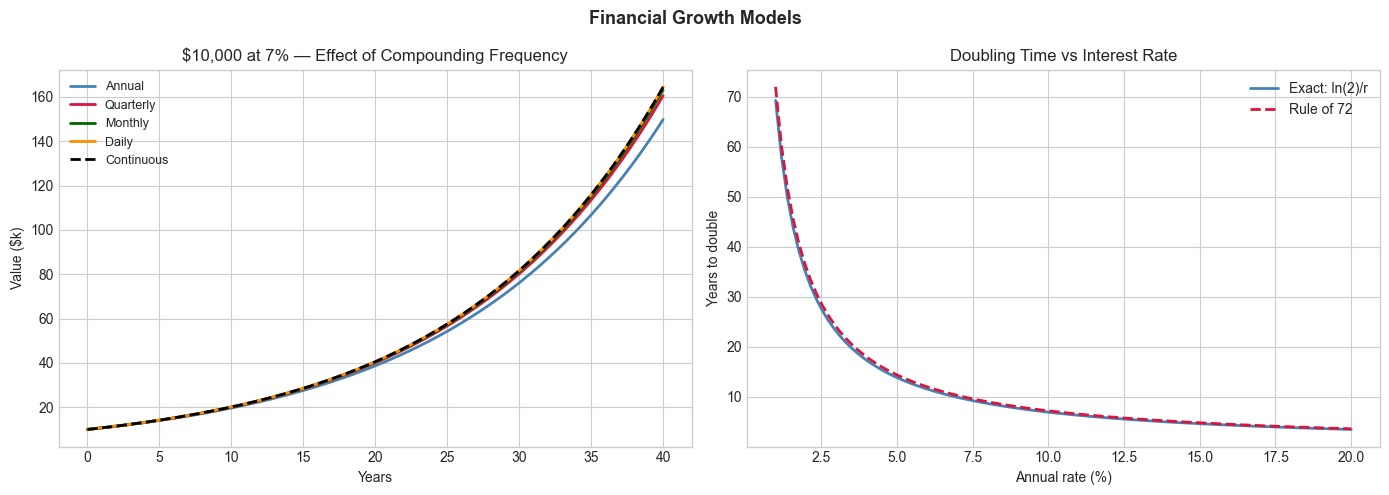

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def compound_interest(P, r, n, t):
    """Compound interest: A = P(1 + r/n)^(nt)."""
    return P * (1 + r/n)**(n*t)

def continuous_compound(P, r, t):
    """Continuous compounding: A = P*e^(rt)."""
    return P * np.exp(r * t)

P0, r = 10000, 0.07  # $10k at 7% annual
t = np.linspace(0, 40, 400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n, label, color in [(1,'Annual','steelblue'),(4,'Quarterly','crimson'),(12,'Monthly','darkgreen'),(365,'Daily','darkorange')]:
    axes[0].plot(t, compound_interest(P0, r, n, t)/1000, color=color, linewidth=2, label=label)
axes[0].plot(t, continuous_compound(P0, r, t)/1000, 'k--', linewidth=2, label='Continuous')
axes[0].set_title('$10,000 at 7% — Effect of Compounding Frequency')
axes[0].set_xlabel('Years'); axes[0].set_ylabel('Value ($k)'); axes[0].legend(fontsize=9)

# Doubling time: rule of 72 (approx) vs exact
rates = np.linspace(0.01, 0.20, 100)
exact_double = np.log(2) / rates
rule72 = 72 / (rates * 100)
axes[1].plot(rates*100, exact_double, color='steelblue', linewidth=2, label='Exact: ln(2)/r')
axes[1].plot(rates*100, rule72, color='crimson', linewidth=2, linestyle='--', label='Rule of 72')
axes[1].set_title('Doubling Time vs Interest Rate'); axes[1].set_xlabel('Annual rate (%)')
axes[1].set_ylabel('Years to double'); axes[1].legend()

plt.suptitle('Financial Growth Models', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Stage 2 — NPV and IRR

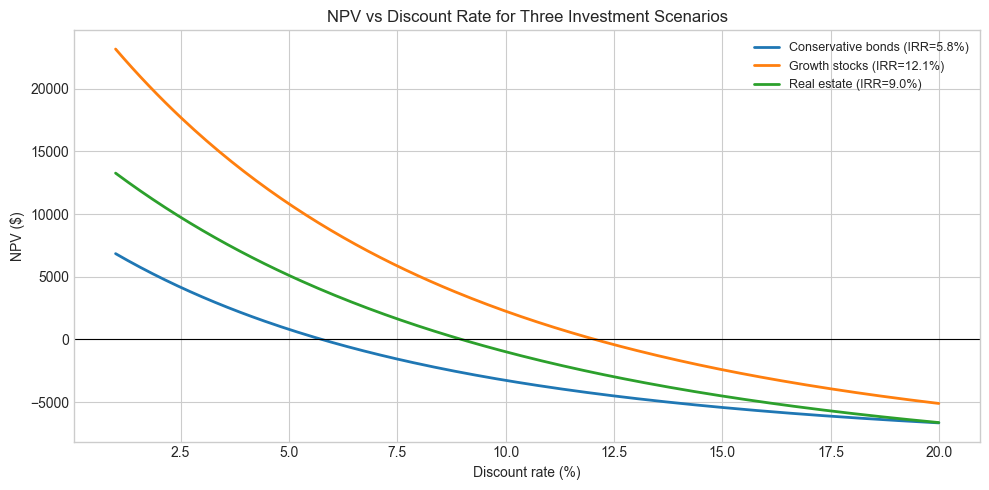

In [2]:
# Net Present Value and Internal Rate of Return
def npv(cashflows, rate):
    """NPV: Σ CFₜ / (1+r)^t."""
    return sum(cf / (1+rate)**t for t, cf in enumerate(cashflows))

def irr(cashflows, tol=1e-6, max_iter=100):
    """Find IRR: the rate where NPV=0 (bisection method)."""
    lo, hi = -0.999, 10.0
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        if npv(cashflows, mid) > 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return mid

# Compare three investment scenarios
scenarios = {
    'Conservative bonds':  [-10000] + [600]*15 + [10000],
    'Growth stocks':       [-10000] + [-500]*3 + [2000]*12 + [15000],
    'Real estate':         [-10000, -2000] + [800]*10 + [20000],
}

rates = np.linspace(0.01, 0.20, 200)
fig, ax = plt.subplots(figsize=(10, 5))
for name, cfs in scenarios.items():
    npvs = [npv(cfs, r) for r in rates]
    irr_val = irr(cfs)
    ax.plot(rates*100, npvs, linewidth=2, label=f'{name} (IRR={irr_val*100:.1f}%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('NPV vs Discount Rate for Three Investment Scenarios')
ax.set_xlabel('Discount rate (%)'); ax.set_ylabel('NPV ($)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---

## Stage 3 — Logistic Savings Model

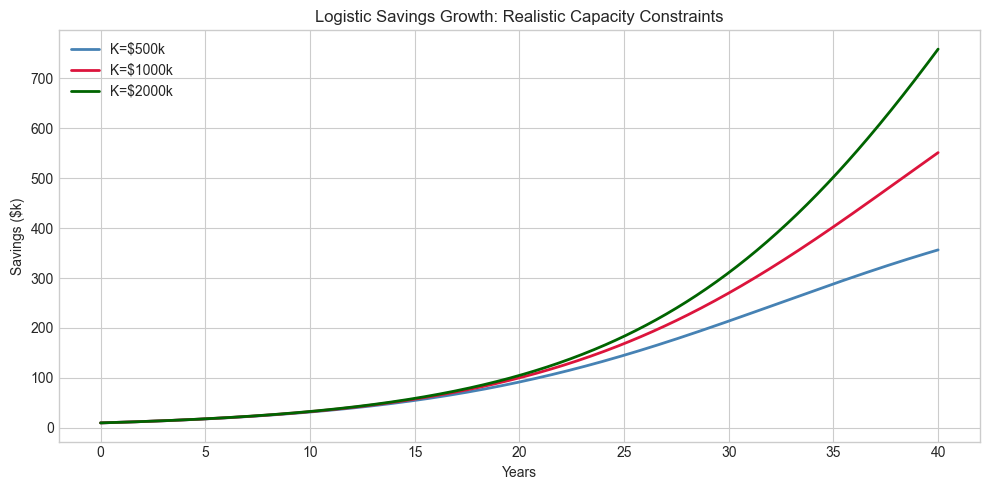

In [3]:
# Savings with diminishing returns (logistic model)
# Motivated by: hard to save the first $100k, harder still above that
def savings_model(t, S0, K, r):
    """Logistic savings growth with capacity K."""
    return K / (1 + (K/S0 - 1) * np.exp(-r * t))

t = np.linspace(0, 40, 500)
fig, ax = plt.subplots(figsize=(10, 5))
for K, color in [(500000,'steelblue'),(1000000,'crimson'),(2000000,'darkgreen')]:
    ax.plot(t, savings_model(t, 10000, K, 0.12)/1000, color=color, linewidth=2, label=f'K=${K//1000}k')
ax.set_title('Logistic Savings Growth: Realistic Capacity Constraints')
ax.set_xlabel('Years'); ax.set_ylabel('Savings ($k)'); ax.legend()
plt.tight_layout(); plt.show()

---

## Results & Reflection

**What was built:** Compound interest calculator, NPV/IRR analysis, and logistic savings model.

**Math used:** Exponential growth (ch042), logistic functions (ch064), iterative root finding for IRR (ch074).

**Extensions:** 1) Add inflation-adjusted returns. 2) Monte Carlo simulation with random return rates. 3) Compare DCA vs lump-sum investing strategies.